# Spatial & Network Data

## *Workshop 3*  [![Open In Colab](https://github.com/oballinger/BASC0005/blob/main/colab-badge.png?raw=1)](https://colab.research.google.com/github/oballinger/BASC0005/blob/main/notebooks/W03.%20Spatial%20Data.ipynb)

In the lecture we followed Ukrainian grain through the Kerch Strait using **AIS** (the Automatic Identification System that ships broadcast) and satellite imagery. Two kinds of data made that possible: **spatial data** (where ships are, which waters they are in, how far apart they are) and **network data** (which ships transfer cargo to which).

Today you'll practise both, on real data:

1. **Vector data** — fishing activity off the Galápagos Islands, detected from AIS by [Global Fishing Watch](https://globalfishingwatch.org). Is the fishing inside or outside national waters?
2. **Nearest-feature analysis** — John Snow's 1854 cholera map and the Broad Street pump.
3. **Raster data** — the same fishing data treated as an image: resolution and raster maths.
4. **Networks** — the London Underground, then the ship-to-ship transfer network from the lecture's Kerch Strait case study.

### Aims
- Turn a table of coordinates into a `GeoDataFrame` and work with points, lines and polygons
- Understand coordinate reference systems (CRS) and when you *must* project your data
- Do a **spatial join** (points in polygons, nearest feature) and aggregate the result
- Use distances and buffers; normalise by area
- Treat a grid as a raster: change resolution and do raster arithmetic
- Build a network from an edge list; measure degree, small-world structure, centrality and communities
- Critically assess spatial and network analyses: spot the problem

**Timing:** about 2 hours. Sections marked *(Extension)* are optional.

**Data:** Fishing effort © [Global Fishing Watch](https://globalfishingwatch.org), CC BY-NC 4.0 (`fishing_effort_v3`). EEZ boundaries: [Marine Regions](https://www.marineregions.org) (Flanders Marine Institute, EEZ v12, CC BY 4.0). Land: [Natural Earth](https://www.naturalearthdata.com). Cholera data: digitised by [Robin Wilson](https://blog.rtwilson.com/john-snows-cholera-data-in-more-formats/) from Snow's map. Tube network: [nicola/tubemaps](https://github.com/nicola/tubemaps). Kerch transfers: [oballinger.github.io/STS](https://oballinger.github.io/STS/).

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams["figure.figsize"] = (9, 6)
URL = "https://storage.googleapis.com/qm2/2627/w03/"

# Part 1: Vector Data

## The story

In July 2020, around 300 Chinese-flagged fishing vessels, mostly **squid jiggers**, gathered off the Galápagos Islands, one of the most protected marine areas on Earth. Ecuador's navy tracked them and it became a diplomatic incident. The fleet was fishing legally *if* it stayed outside Ecuador's **Exclusive Economic Zone** (EEZ, the area up to 200 nautical miles from a country's coast, where that country controls fishing).

**Question:** how much fishing happens inside each country's EEZ, and how much on the high seas just outside?

## The data

Global Fishing Watch uses a machine-learning model on AIS tracks to estimate when a vessel is fishing, then sums **fishing hours** on a grid of 0.1° × 0.1° cells (roughly 11 km × 11 km near the equator). I've extracted annual totals for a box around the Galápagos, 2020–2024, by flag state and gear type.

In [2]:
effort = pd.read_csv(URL + "gfw_effort_galapagos.csv")
effort.head()

,year,lat,lon,flag,geartype,fishing_hours
0,2020,-11.95,-101.95,JPN,drifting_longlines,4.84
1,2020,-11.95,-101.85,JPN,drifting_longlines,3.47
2,2020,-11.95,-101.75,JPN,drifting_longlines,4.56
3,2020,-11.95,-101.65,ESP,drifting_longlines,1.47
4,2020,-11.95,-101.65,JPN,drifting_longlines,6.50


Each row is one **grid cell × year × flag × gear type**. `lat` and `lon` are the centre of the cell. Which fleets fish here?

In [3]:
effort.groupby(["flag", "geartype"])["fishing_hours"].sum().sort_values(ascending=False).head(10)

flag  geartype          
CHN   squid_jigger          1121573.44
PER   other_purse_seines     324463.51
CHN   fishing                173519.92
ECU   drifting_longlines     142744.38
COL   trawlers               119049.21
ECU   tuna_purse_seines      104434.55
PER   tuna_purse_seines       68560.39
ECU   fishing                 49414.08
PER   purse_seines            35940.55
COL   fishing                 27908.00
Name: fishing_hours, dtype: float64

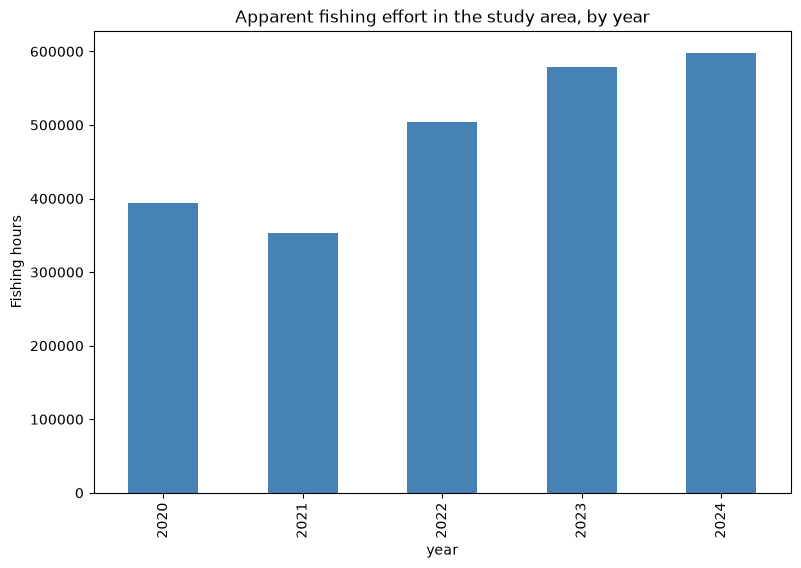

In [4]:
effort.groupby("year")["fishing_hours"].sum().plot(kind="bar", color="steelblue")
plt.ylabel("Fishing hours")
plt.title("Apparent fishing effort in the study area, by year")
plt.show()

## Points: from a table to a GeoDataFrame

A CSV with `lat`/`lon` columns is just numbers. To do spatial operations we need a **geometry** column. A `GeoDataFrame` is a pandas DataFrame with a geometry column and a **coordinate reference system (CRS)** that says what the coordinates mean.

`EPSG:4326` is plain longitude/latitude in degrees (what GPS and AIS report). Let's make one for 2024.

In [5]:
e24 = effort[effort["year"] == 2024]

cells = gpd.GeoDataFrame(
    e24,
    geometry=gpd.points_from_xy(e24["lon"], e24["lat"]),  # x = longitude, y = latitude
    crs="EPSG:4326",
)
print(cells.crs)
cells.head(3)

EPSG:4326


,year,lat,lon,flag,geartype,fishing_hours,geometry
135587,2024,-11.95,-101.85,ECU,fishing,0.91,POINT (-101.85 -11.95)
135588,2024,-11.95,-101.65,JPN,drifting_longlines,1.43,POINT (-101.65 -11.95)
135589,2024,-11.95,-101.55,JPN,drifting_longlines,0.92,POINT (-101.55 -11.95)


## Polygons (and lines)

Now the areas we want to aggregate into. The EEZ file is a **GeoJSON** of polygons, one row per EEZ, just like the borough table in the lecture. I've also loaded land polygons for context.

In [6]:
eez = gpd.read_file(URL + "eez_galapagos.geojson")
land = gpd.read_file(URL + "land_galapagos.geojson")
eez

,eez,sovereign,mrgid,geometry
0,Peru,Peru,8432,"POLYGON ((-80.30629 -3.3957, -80.29382 -3.4106..."
1,Panama,Panama,8423,"MULTIPOLYGON (((-78.42528 8, -78.42378 7.97825..."
2,Costa Rica,Costa Rica,8424,"POLYGON ((-82.91337 8, -84.31667 5, -84.31667 ..."
3,Colombia,Colombia,8426,"MULTIPOLYGON (((-76.92174 8, -76.73192 7.99777..."
4,Ecuador (Galapagos),Ecuador,8403,"POLYGON ((-87.1365 2.14762, -86.47134 1.14687,..."
5,Ecuador (mainland),Ecuador,8431,"POLYGON ((-83.45583 1.45667, -78.85013 1.45654..."


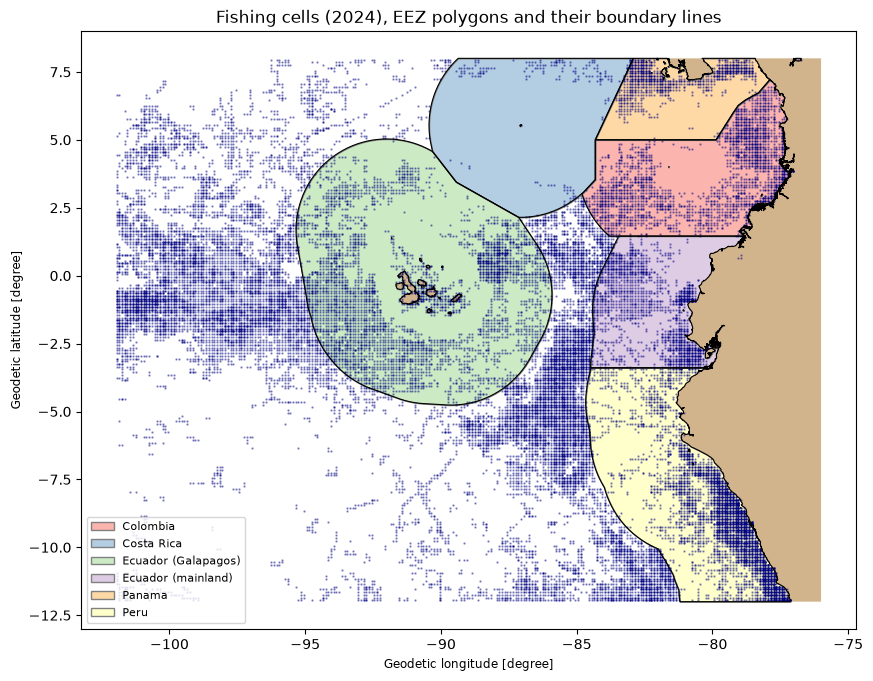

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
eez.plot(ax=ax, column="eez", cmap="Pastel1", edgecolor="grey", legend=True,
         legend_kwds={"loc": "lower left", "fontsize": 8})
eez.boundary.plot(ax=ax, color="black", linewidth=0.8)      # .boundary turns polygons into LINES
land.plot(ax=ax, color="tan")
cells.plot(ax=ax, markersize=0.5, color="navy", alpha=0.4)  # points
ax.set_title("Fishing cells (2024), EEZ polygons and their boundary lines")
plt.show()

All three vector types are on this map: **points** (fishing cells), **lines** (EEZ boundaries) and **polygons** (EEZs, land). Notice the big empty arc west of Ecuador: that's the Galápagos EEZ. Look at the edges of it.

### Exercise 1
Make the same map, but plot only **squid jigger** cells (`geartype == "squid_jigger"`) and colour them by `fishing_hours` (hint: `column="fishing_hours"`, and try `vmax=500`). In one sentence: where is the squid fleet fishing relative to the EEZ boundaries?

In [8]:
# your code here

## Coordinate Reference Systems

Degrees are fine for *storing* locations, but they are not a unit of distance or area: one degree of longitude is 111 km at the equator but only 69 km in London, and 0 km at the poles. So before we measure anything, we **project** the data into a CRS whose units are metres.

Watch what happens if we ask for the area of each EEZ while still in degrees:

In [9]:
eez.area   # geopandas warns you: the answer is in "square degrees", which is meaningless

/var/folders/m4/ncmwmfqx40b17h9dj11msd740000gn/T/ipykernel_74817/2218338212.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  eez.area   # geopandas warns you: the answer is in "square degrees", which is meaningless


0    34.994628
1    13.654362
2    32.465182
3    26.670074
4    68.404455
5    19.203443
dtype: float64

There's no single "correct" projection: every flat map distorts something. For areas and distances in this region I'll use a **Lambert Azimuthal Equal-Area** projection centred on the Galápagos (units: metres). `.to_crs()` converts every coordinate.

In [10]:
PROJ = "+proj=laea +lat_0=-2 +lon_0=-89 +datum=WGS84 +units=m"   # equal-area, centred on our study area

eez_m = eez.to_crs(PROJ)
eez_m["area_km2"] = eez_m.area / 1e6
eez_m[["eez", "area_km2"]].round(0)

,eez,area_km2
0,Peru,426546.0
1,Panama,167085.0
2,Costa Rica,397682.0
3,Colombia,327605.0
4,Ecuador (Galapagos),841247.0
5,Ecuador (mainland),236292.0


(These are the parts of each EEZ inside our study box, not the whole EEZ.)

## Spatial join: which EEZ is each cell in?

A normal `merge` matches rows on a shared key. A **spatial join** matches rows on a spatial relationship, here "this point is *within* that polygon". Both layers must be in the **same CRS**.

We use `how="left"` so we keep points that fall in *no* EEZ: those are on the high seas.

In [11]:
joined = gpd.sjoin(cells, eez[["eez", "geometry"]], how="left", predicate="within")
joined["eez"] = joined["eez"].fillna("High seas")

print(len(cells), "cells before,", len(joined), "rows after")   # always check a join didn't duplicate rows
joined[["lat", "lon", "flag", "geartype", "fishing_hours", "eez"]].head()

29447 cells before, 29447 rows after


,lat,lon,flag,geartype,fishing_hours,eez
135587,-11.95,-101.85,ECU,fishing,0.91,High seas
135588,-11.95,-101.65,JPN,drifting_longlines,1.43,High seas
135589,-11.95,-101.55,JPN,drifting_longlines,0.92,High seas
135590,-11.95,-101.45,JPN,drifting_longlines,0.62,High seas
135591,-11.95,-100.75,ECU,fishing,0.33,High seas


Now it's a normal pandas `groupby`: this is **zonal statistics** (vector–vector) from the lecture.

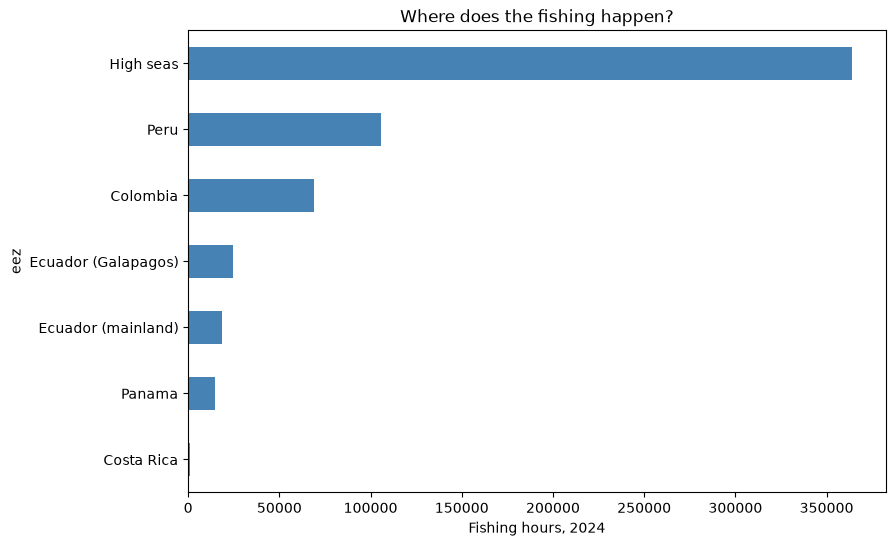

eez
High seas              60.9
Peru                   17.7
Colombia               11.6
Ecuador (Galapagos)     4.1
Ecuador (mainland)      3.1
Panama                  2.4
Costa Rica              0.2
Name: fishing_hours, dtype: float64


In [12]:
by_eez = joined.groupby("eez")["fishing_hours"].sum().sort_values()
by_eez.plot(kind="barh", color="steelblue")
plt.xlabel("Fishing hours, 2024")
plt.title("Where does the fishing happen?")
plt.show()

print((100 * by_eez / by_eez.sum()).round(1).sort_values(ascending=False))

Most of the fishing in this box is on the **high seas**. To map the EEZ totals, merge them back onto the polygons (an ordinary attribute join) and make a **choropleth**.

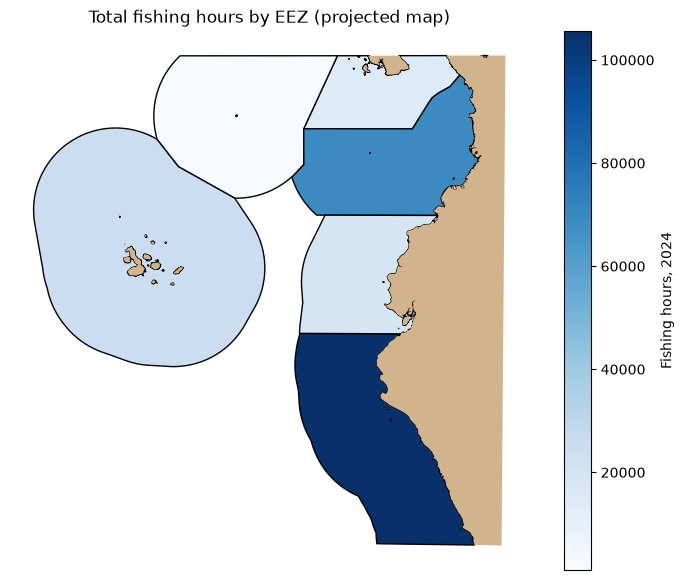

In [13]:
eez_m = eez_m.merge(by_eez.rename("hours").reset_index(), on="eez", how="left")

fig, ax = plt.subplots(figsize=(9, 7))
eez_m.plot(ax=ax, column="hours", cmap="Blues", edgecolor="black", legend=True,
           legend_kwds={"label": "Fishing hours, 2024"})
land.to_crs(PROJ).plot(ax=ax, color="tan")
ax.set_title("Total fishing hours by EEZ (projected map)")
ax.set_axis_off()
plt.show()

### Area matters

Peru's slice of the box is much bigger than Panama's. Is Peru's EEZ fished more *intensively*, or just bigger? A choropleth of **totals** mostly shows you which polygons are large. Normalise by area:

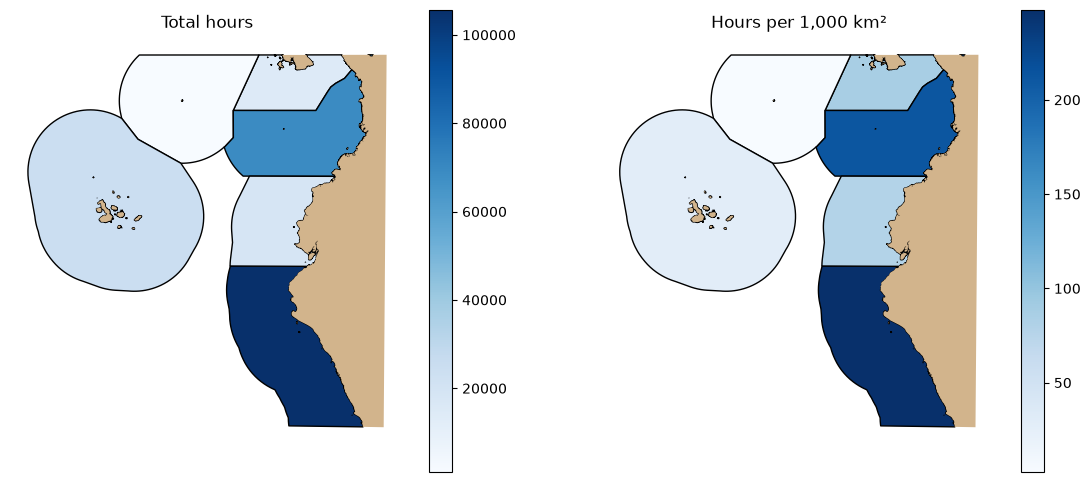

,eez,hours,area_km2,hours_per_1000km2
0,Peru,105624.6,426546.3,247.6
3,Colombia,69229.0,327605.2,211.3
1,Panama,14612.8,167085.5,87.5
5,Ecuador (mainland),18684.5,236292.4,79.1
4,Ecuador (Galapagos),24674.6,841246.6,29.3
2,Costa Rica,1048.2,397682.0,2.6


In [14]:
eez_m["hours_per_1000km2"] = 1000 * eez_m["hours"] / eez_m["area_km2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, col, title in zip(axes, ["hours", "hours_per_1000km2"], ["Total hours", "Hours per 1,000 km²"]):
    eez_m.plot(ax=ax, column=col, cmap="Blues", edgecolor="black", legend=True)
    land.to_crs(PROJ).plot(ax=ax, color="tan")
    ax.set_title(title)
    ax.set_axis_off()
plt.show()

eez_m[["eez", "hours", "area_km2", "hours_per_1000km2"]].sort_values("hours_per_1000km2", ascending=False).round(1)

**Question:** Which ranking would you report, and why? The Galápagos EEZ is huge but lightly fished: is that because it's protected, or could it be something about *who* the data can see? (Hint: AIS is mandatory for large vessels but many small coastal boats don't carry it.)

A related trap is the **Modifiable Areal Unit Problem (MAUP)**: your conclusions can change just by drawing the zones differently (EEZs vs. 1° grid squares vs. our study box). We'll see it again with rasters.

### Exercise 2
Which flag states fish on the high seas, and which inside EEZs? Using `joined`, make a table with EEZs as rows, flags as columns and the sum of fishing hours as values (hint: `pd.crosstab(..., values=..., aggfunc="sum")` or `groupby([...]).sum().unstack()`). Restrict to the five flags with the most hours overall. What share of Chinese-flagged (`CHN`) fishing is on the high seas?

In [15]:
# your code here

## Distance and buffers

Snow's insight and the lecture's ship-to-ship rule ("within 500 m for 2 hours") are both about **distance**. Let's ask: how far from the Galápagos EEZ boundary does the squid fleet fish? We'll use 2020, the year of the incident.

Distances must be computed in a projected CRS (metres). We make the distance **negative** for cells inside the EEZ, so 0 is exactly on the boundary line.

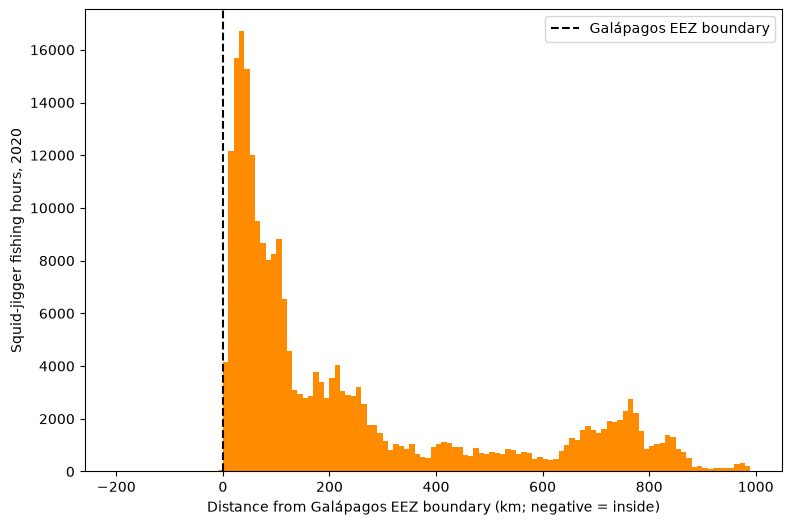

In [16]:
galapagos = eez_m.loc[eez_m["eez"] == "Ecuador (Galapagos)", "geometry"].iloc[0]

squid20 = effort[(effort["year"] == 2020) & (effort["geartype"] == "squid_jigger")]
squid20 = gpd.GeoDataFrame(squid20, geometry=gpd.points_from_xy(squid20["lon"], squid20["lat"]),
                           crs="EPSG:4326").to_crs(PROJ)

dist_km = squid20.distance(galapagos.boundary) / 1000
squid20["dist_km"] = np.where(squid20.within(galapagos), -dist_km, dist_km)

plt.hist(squid20["dist_km"], bins=np.arange(-200, 1000, 10), weights=squid20["fishing_hours"], color="darkorange")
plt.axvline(0, color="black", linestyle="--", label="Galápagos EEZ boundary")
plt.xlabel("Distance from Galápagos EEZ boundary (km; negative = inside)")
plt.ylabel("Squid-jigger fishing hours, 2020")
plt.legend()
plt.show()

**Question:** Describe the shape of this distribution. What does the sharp edge at 0 tell you about how the fleet responds to the boundary? Does this plot show the fleet was fishing *illegally*?

### Buffers: an approximate marine reserve

The **Galápagos Marine Reserve** extends 40 nautical miles from the islands' baselines. A **buffer** draws a zone of fixed distance around a geometry. We can approximate the reserve by buffering the island polygons by 40 nm (1 nm = 1,852 m), in metres, of course.

Approximate reserve area: 134,619 km²  (published figures: roughly 133,000-138,000 km²)


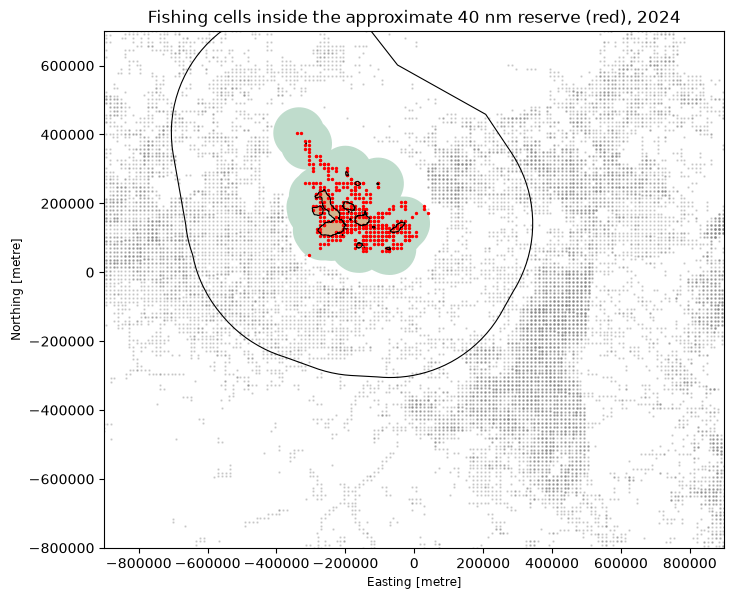

flag  geartype         
ECU   fishing              7178.20
      set_longlines        1321.74
      pole_and_line         192.61
      tuna_purse_seines     166.50
      trawlers               61.03
Name: fishing_hours, dtype: float64

In [17]:
islands = land[land["name"] == "Galapagos"].to_crs(PROJ)
reserve = islands.union_all().buffer(40 * 1852)       # one shape: all islands merged, then buffered
print(f"Approximate reserve area: {reserve.area / 1e6:,.0f} km²  (published figures: roughly 133,000-138,000 km²)")

cells_m = cells.to_crs(PROJ)
in_reserve = cells_m[cells_m.within(reserve)]

fig, ax = plt.subplots(figsize=(8, 7))
gpd.GeoSeries([galapagos], crs=PROJ).boundary.plot(ax=ax, color="black", linewidth=0.8)
gpd.GeoSeries([reserve], crs=PROJ).plot(ax=ax, color="seagreen", alpha=0.3)
islands.plot(ax=ax, color="tan")
cells_m.plot(ax=ax, markersize=0.5, color="grey", alpha=0.3)
in_reserve.plot(ax=ax, markersize=2, color="red")
ax.set_xlim(-900e3, 900e3); ax.set_ylim(-800e3, 700e3)
ax.set_title("Fishing cells inside the approximate 40 nm reserve (red), 2024")
plt.show()

in_reserve.groupby(["flag", "geartype"])["fishing_hours"].sum().sort_values(ascending=False).head()

**Question:** Almost all fishing inside the reserve is by Ecuadorian vessels. Does that mean the reserve is being violated? What would you need to know? (Local artisanal fleets have permitted zones; our reserve is also an approximation: the real one is drawn from straight baselines around the whole archipelago, not circles around each island; and our cells are 11 km squares represented by their centre point.)

### Exercise 3
Repeat the buffer analysis with a **wrong** buffer: `land[land["name"] == "Galapagos"].union_all().buffer(40 * 1852)`, i.e. buffer while still in EPSG:4326. Print its `.bounds`. What has gone wrong, and why didn't Python stop you?

In [18]:
# your code here

# Part 2: The Broad Street Pump (nearest feature)

In 1854, cholera killed hundreds of people in Soho. Most doctors blamed "bad air". John Snow mapped deaths and water pumps and argued the Broad Street pump was the source. His core method was a **nearest-feature** analysis: which pump was closest to each household?

The data: one point per address, with the number of deaths there, and the pumps. Both are plain CSVs of longitude/latitude.

489 deaths at 250 addresses; 8 pumps


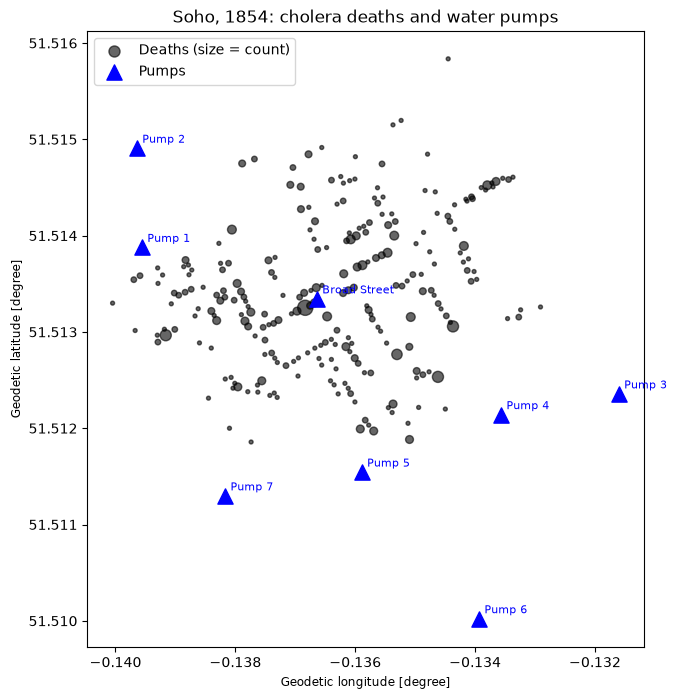

In [19]:
deaths = pd.read_csv(URL + "snow_deaths.csv")
pumps = pd.read_csv(URL + "snow_pumps.csv")

deaths = gpd.GeoDataFrame(deaths, geometry=gpd.points_from_xy(deaths.lon, deaths.lat), crs="EPSG:4326")
pumps = gpd.GeoDataFrame(pumps, geometry=gpd.points_from_xy(pumps.lon, pumps.lat), crs="EPSG:4326")
print(deaths["deaths"].sum(), "deaths at", len(deaths), "addresses;", len(pumps), "pumps")

fig, ax = plt.subplots(figsize=(8, 8))
deaths.plot(ax=ax, markersize=deaths["deaths"] * 8, color="black", alpha=0.6, label="Deaths (size = count)")
pumps.plot(ax=ax, color="blue", marker="^", markersize=120, label="Pumps")
for _, p in pumps.iterrows():
    ax.annotate(p["name"], (p.lon, p.lat), xytext=(4, 4), textcoords="offset points", fontsize=8, color="blue")
ax.legend()
ax.set_title("Soho, 1854: cholera deaths and water pumps")
plt.show()

## Spot the problem

A colleague ran the nearest-pump analysis below and wrote:

> "Assigning each address to its nearest pump, 276 of 489 deaths (56%) were closest to Broad Street. The pump explains only about half the outbreak."

Run it, then find what's wrong. (Read any warnings carefully.)

In [20]:
# Colleague's analysis
nearest = gpd.sjoin_nearest(deaths, pumps[["name", "geometry"]], how="left")
by_pump = nearest.groupby("name")["deaths"].sum().sort_values(ascending=False)
print(by_pump)
print(f"Share nearest Broad Street: {by_pump['Broad Street'] / by_pump.sum():.0%}")

name
Broad Street    276
Pump 4           78
Pump 1           71
Pump 5           46
Pump 7           15
Pump 2            3
Name: deaths, dtype: int64
Share nearest Broad Street: 56%


/usr/local/lib/python3.12/dist-packages/geopandas/array.py:438: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


### Exercise 4
1. Explain in two sentences what's wrong with the analysis above. (Hint: at London's latitude, how many km is one degree of longitude compared with one degree of latitude? Which pumps does that favour?)
2. Fix it: project both layers to the **British National Grid**, `EPSG:27700` (units: metres), and redo the join. Add `distance_col="dist_m"` to get the distance to the nearest pump.
3. How many deaths are now nearest Broad Street? How many *addresses* changed pump?
4. Plot the deaths coloured by their (corrected) nearest pump.

In [21]:
# your code here

**Question:** Snow actually used *walking* distance along streets, not straight lines. Why might that matter here, and what kind of data would you need to do it? (Hint: Part 4 of this notebook.)

# Part 3: Raster Data

A raster is a grid of cells, each holding a value: a satellite image, night-time lights, or our fishing data. The GFW data is *already* a raster, just stored as a table (one row per cell). Let's turn it into a 2-D array, i.e. an image.

Raster shape (rows, cols): (200, 260) | cells with fishing: 17424


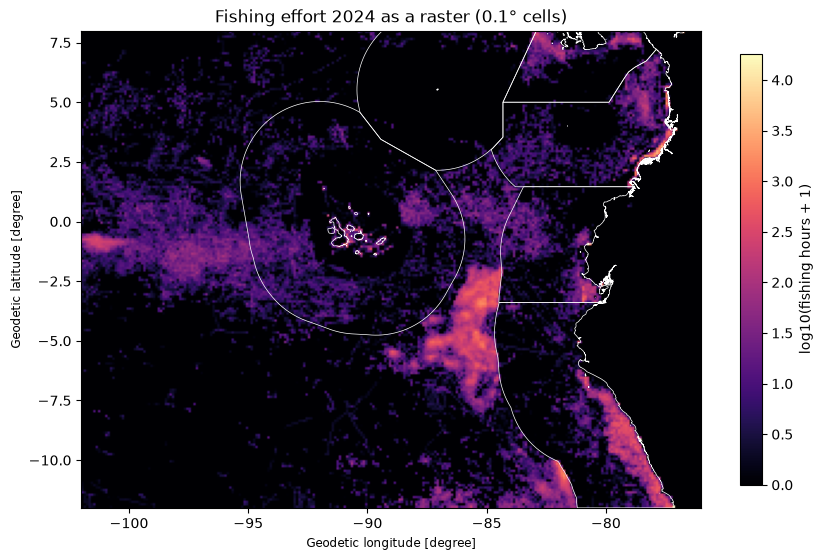

In [22]:
def to_raster(df, res=0.1, lon0=-102, lon1=-76, lat0=-12, lat1=8):
    # Sum fishing hours onto a regular grid; returns a 2-D array (rows = latitude, columns = longitude)
    nrow, ncol = round((lat1 - lat0) / res), round((lon1 - lon0) / res)
    row = ((df["lat"] - lat0) // res).astype(int)
    col = ((df["lon"] - lon0) // res).astype(int)
    grid = np.zeros((nrow, ncol))
    np.add.at(grid, (row, col), df["fishing_hours"])   # add each row's hours into its cell
    return grid

EXTENT = [-102, -76, -12, 8]   # left, right, bottom, top (degrees)
r24 = to_raster(effort[effort["year"] == 2024])
print("Raster shape (rows, cols):", r24.shape, "| cells with fishing:", (r24 > 0).sum())

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(np.log10(r24 + 1), origin="lower", extent=EXTENT, cmap="magma")
eez.boundary.plot(ax=ax, color="white", linewidth=0.5)
plt.colorbar(im, label="log10(fishing hours + 1)", shrink=0.7)
ax.set_title("Fishing effort 2024 as a raster (0.1° cells)")
plt.show()

Two things to notice: we used a **log scale** (effort is extremely skewed: a few cells have thousands of hours), and `origin="lower"` because row 0 of our array is the *southernmost* latitude.

## Resolution

The lecture compared 30 m, 50 cm and 10 cm imagery. **Resolution** is the size of a cell. Coarser cells are smaller files, but detail is lost. Let's aggregate our 0.1° grid to 0.5° and 1°:

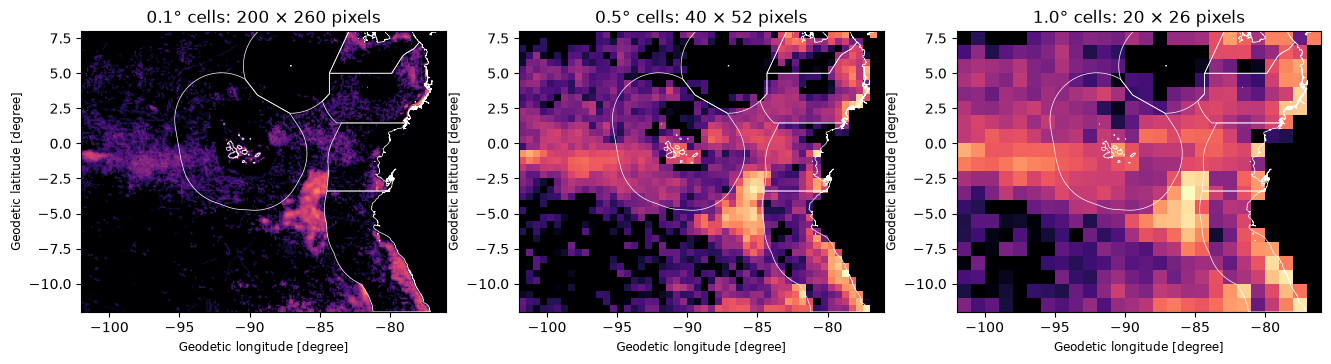

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res in zip(axes, [0.1, 0.5, 1.0]):
    g = to_raster(effort[effort["year"] == 2024], res=res)
    ax.imshow(np.log10(g + 1), origin="lower", extent=EXTENT, cmap="magma")
    eez.boundary.plot(ax=ax, color="white", linewidth=0.5)
    ax.set_title(f"{res}° cells: {g.shape[0]} × {g.shape[1]} pixels")
plt.show()

**Question:** At 1° resolution (about 110 km), could you still see that the squid fleet stops at the Galápagos EEZ boundary? Which analysis from Part 1 would give a different answer at 1°? (This is the MAUP again.)

## Raster maths

Rasters on the same grid can be added, subtracted or divided cell by cell, like the lecture's night-time lights 1992 vs 2012 example. Here: where did fishing *increase* or *decrease* between 2020 and 2024?

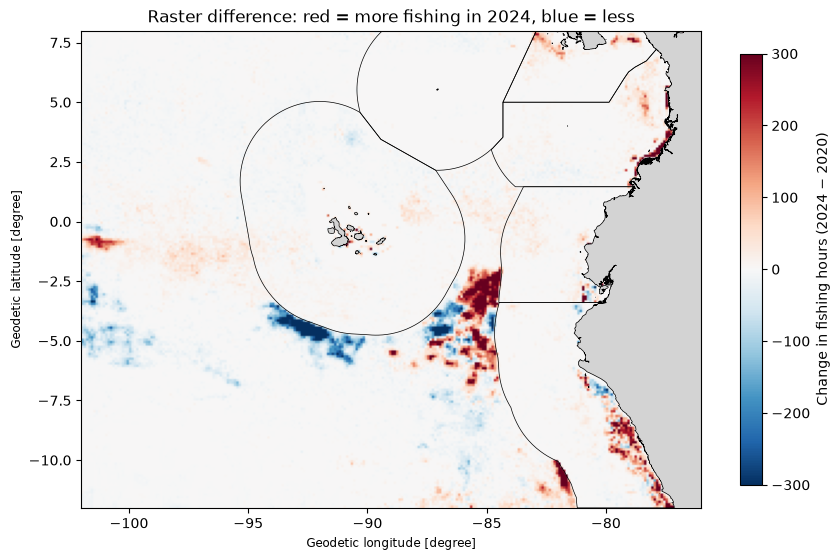

In [24]:
r20 = to_raster(effort[effort["year"] == 2020])
change = r24 - r20       # one line of raster maths: every cell at once

lim = 300
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(change, origin="lower", extent=EXTENT, cmap="RdBu_r", vmin=-lim, vmax=lim)
eez.boundary.plot(ax=ax, color="black", linewidth=0.5)
land.plot(ax=ax, color="lightgrey")
plt.colorbar(im, label="Change in fishing hours (2024 − 2020)", shrink=0.7)
ax.set_title("Raster difference: red = more fishing in 2024, blue = less")
plt.show()

### Exercise 5
Make the same difference map for **squid jiggers only**. Then compute one number: the total change in squid-jigger hours inside the box. Is the fleet fishing more or less, and has it moved?

In [25]:
# your code here

## (Extension) Spatial autocorrelation: why regressions on maps need care

The lecture warned that *things closer together have more in common*. Check it on our raster: correlate each cell's (log) effort with its eastern neighbour's, then with a random cell's.

In [26]:
logr = np.log10(r24 + 1)
here, east = logr[:, :-1].ravel(), logr[:, 1:].ravel()
rng = np.random.default_rng(0)
print("Correlation with neighbour:   ", round(np.corrcoef(here, east)[0, 1], 2))
print("Correlation with random cell: ", round(np.corrcoef(here, rng.permutation(east))[0, 1], 2))

Correlation with neighbour:    0.81
Correlation with random cell:  0.0


Neighbouring cells are strongly correlated. If each cell were a row in a regression, you would have far fewer *independent* observations than rows, and your standard errors would be too small. Spatial regression methods exist to handle this.

# Part 4: Networks

A network is a set of **nodes** (things) and **edges** (relationships). Vocabulary from the lecture:

- **Degree**: how many edges a node has
- **Directed** (A → B isn't B → A) vs **undirected**; **weighted** edges have a strength or cost
- Networks are usually stored as an **edge list**: one row per edge, which is exactly what you load with pandas

## The London Underground

Stations are nodes; an edge joins two adjacent stations, weighted by travel time in minutes. (This dataset is c. 2007: no Overground or Elizabeth line.)

In [27]:
TUBE = "https://raw.githubusercontent.com/nicola/tubemaps/master/datasets/"
stations = pd.read_csv(TUBE + "london.stations.csv")
connections = pd.read_csv(TUBE + "london.connections.csv")

# the edge list uses station ids: swap in names
name = stations.set_index("id")["name"]
edges = pd.DataFrame({"source": connections["station1"].map(name),
                      "target": connections["station2"].map(name),
                      "time": connections["time"]})
edges.head()

,source,target,time
0,Baker Street,Marylebone,1
1,Baker Street,Regent's Park,2
2,Charing Cross,Embankment,1
3,Charing Cross,Picadilly Circus,2
4,Edgware Road (B),Marylebone,2


302 stations, 349 links


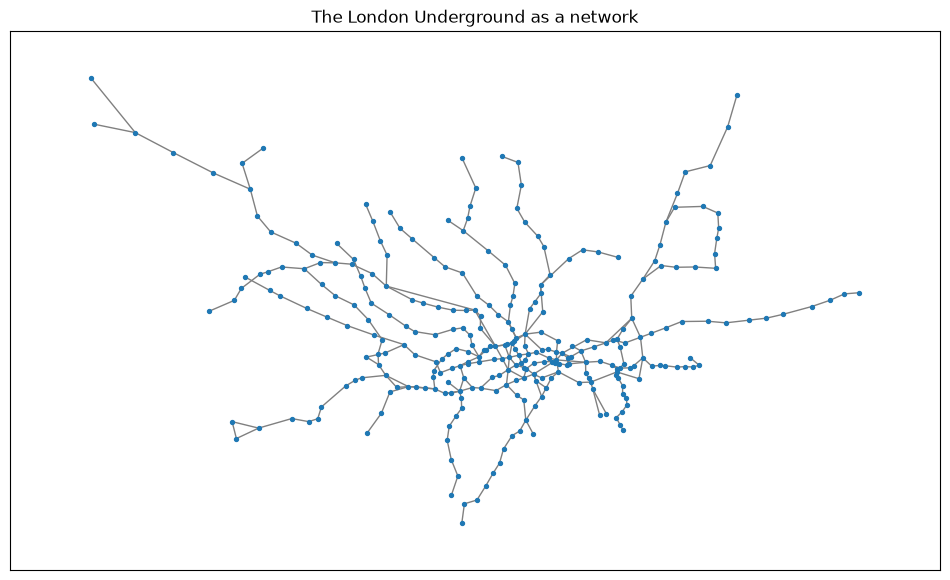

In [28]:
tube = nx.from_pandas_edgelist(edges, "source", "target", edge_attr="time")
print(tube.number_of_nodes(), "stations,", tube.number_of_edges(), "links")

pos = {r["name"]: (r["longitude"], r["latitude"]) for _, r in stations.iterrows()}   # draw nodes at their real location
fig, ax = plt.subplots(figsize=(12, 7))
nx.draw_networkx(tube, pos=pos, ax=ax, node_size=8, with_labels=False, edge_color="grey")
ax.set_title("The London Underground as a network")
plt.show()

In [29]:
route = nx.shortest_path(tube, "Brixton", "Camden Town", weight="time")
print(" -> ".join(route))
print(nx.shortest_path_length(tube, "Brixton", "Camden Town", weight="time"), "minutes")

Brixton -> Stockwell -> Vauxhall -> Pimlico -> Victoria -> Green Park -> Oxford Circus -> Warren Street -> Euston -> Camden Town
19 minutes


Journey planners do exactly this (with better data). Note `weight="time"`: without it, networkx finds the route with the fewest *stops*, not the fastest.

## The Kerch Strait transfer network

Now the lecture's case study. Using AIS, a ship-to-ship (STS) transfer was detected when two ships stayed within 500 m of each other for 2+ hours. Each transfer is an edge between two vessels. The data covers February 2022 to August 2023.

In [30]:
vessels = pd.read_csv(URL + "kerch_vessels.csv")
transfers = pd.read_csv(URL + "kerch_transfers.csv", parse_dates=["date"])
print(len(vessels), "vessels,", len(transfers), "transfers")
display(vessels.head())
transfers.head()

722 vessels, 6530 transfers


,vessel_id,name,imo,vessel_type,type_detail,flag,dwt,length_m,sanctioned,named_in_grain_reports
0,0,Oxana-V,9077317,bulk carrier,bulk carrier,Panama,44822.0,176.0,0,0
1,1,Volgo-Don 5043,8866321,general cargo,general cargo,Russia,3650.0,138.0,0,1
2,2,Kavkaz V,9104574,bulk carrier,bulk carrier,Panama,45664.0,178.0,0,0
3,3,Yekaterina,9874791,general cargo,general cargo,Russia,7867.0,139.0,0,0
4,4,Amazon,9233260,bulk carrier,bulk carrier,Greece,74910.0,217.0,0,0


,vessel_1,vessel_2,date
0,0,1,2022-02-24
1,8,11,2022-02-24
2,7,8,2022-02-24
3,8,9,2022-02-24
4,2,6,2022-02-24


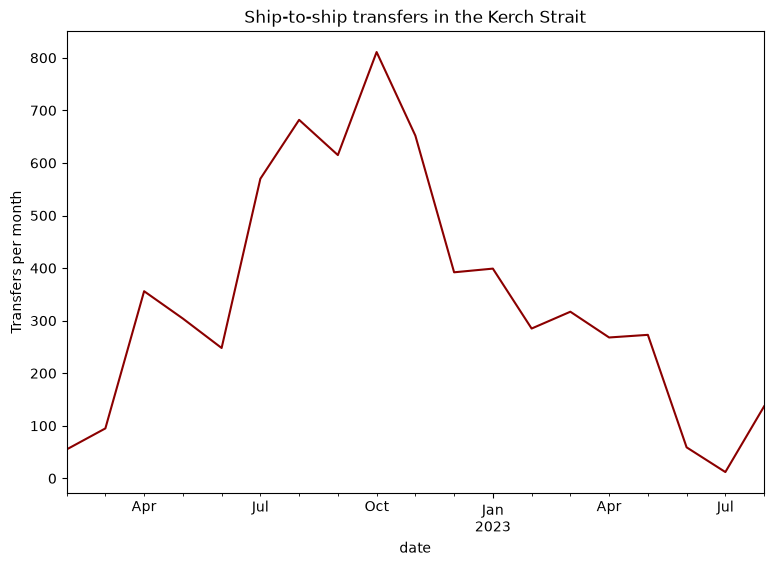

In [31]:
transfers.set_index("date").resample("MS").size().plot(color="darkred")
plt.ylabel("Transfers per month")
plt.title("Ship-to-ship transfers in the Kerch Strait")
plt.show()

Two ships often transfer many times. We'll collapse repeated transfers into one **weighted** edge (weight = number of transfers), and attach vessel attributes to the nodes.

In [32]:
pairs = (transfers.groupby(["vessel_1", "vessel_2"]).size()
         .rename("n_transfers").reset_index())
kerch = nx.from_pandas_edgelist(pairs, "vessel_1", "vessel_2", edge_attr="n_transfers")
nx.set_node_attributes(kerch, vessels.set_index("vessel_id")["name"].to_dict(), "name")
print(kerch.number_of_nodes(), "vessels,", kerch.number_of_edges(), "distinct transfer partnerships")

722 vessels, 4009 distinct transfer partnerships


## A few hubs, many ordinary nodes

The **degree distribution** tells you whether a network is *regular* (everyone has similar numbers of links) or *heavy-tailed* (a few hubs).

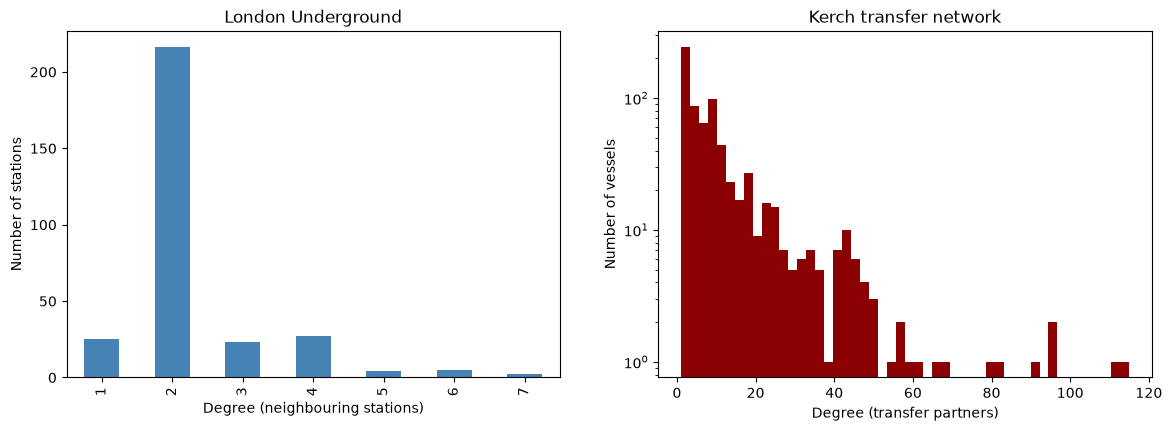

Kerch degree: median 6.0 | 99th percentile 68.0 | max 115


In [33]:
tube_deg = pd.Series(dict(tube.degree()))
kerch_deg = pd.Series(dict(kerch.degree()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
tube_deg.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set(title="London Underground", xlabel="Degree (neighbouring stations)", ylabel="Number of stations")
axes[1].hist(kerch_deg, bins=50, color="darkred")
axes[1].set(title="Kerch transfer network", xlabel="Degree (transfer partners)", ylabel="Number of vessels", yscale="log")
plt.show()

print("Kerch degree: median", kerch_deg.median(), "| 99th percentile", kerch_deg.quantile(0.99).round(), "| max", kerch_deg.max())

**Question:** Why might a shipping network have hubs while the tube can't? (Think about physical constraints on a station vs. a large bulk carrier.)

## It's a small world

A **small world** has short paths between nodes *and* high **clustering** (your partners are also partners of each other). We compare with a **random network** with the same number of nodes and edges. Path lengths only make sense within a connected piece, so we use the largest **connected component**.

In [34]:
lcc = kerch.subgraph(max(nx.connected_components(kerch), key=len)).copy()
rand = nx.gnm_random_graph(lcc.number_of_nodes(), lcc.number_of_edges(), seed=1)
rand = rand.subgraph(max(nx.connected_components(rand), key=len))

summary = pd.DataFrame({
    "Kerch": [nx.average_shortest_path_length(lcc), nx.average_clustering(lcc)],
    "Random network": [nx.average_shortest_path_length(rand), nx.average_clustering(rand)],
}, index=["Average path length", "Clustering coefficient"]).round(3)
summary

,Kerch,Random network
Average path length,3.304,2.947
Clustering coefficient,0.324,0.016


Paths are about as short as in a random network, but clustering is roughly 20 times higher: a small world.

## Who matters? Centrality

Three ways to be central (from the lecture):

- **Degree**: how many partners (the popular one)
- **Betweenness**: share of shortest paths passing through you (the broker)
- **Eigenvector**: connected to other well-connected nodes (the insider)

In [35]:
cent = pd.DataFrame({
    "degree": nx.degree_centrality(kerch),
    "betweenness": nx.betweenness_centrality(kerch),
    "eigenvector": nx.eigenvector_centrality(kerch, max_iter=1000),
})
cent = vessels.set_index("vessel_id").join(cent)

cent.sort_values("betweenness", ascending=False)[["name", "vessel_type", "flag", "degree", "betweenness", "eigenvector"]].head(10)

,name,vessel_type,flag,degree,betweenness,eigenvector
vessel_id,,,,,,
81,Vladimir Monomakh,tanker,Russia,0.131761,0.139141,0.005202
104,Kavkaz II,bulk carrier,Malta,0.127601,0.067158,0.097071
16,Horasan,bulk carrier,Panama,0.131761,0.060620,0.207790
182,Barla,bulk carrier,Panama,0.155340,0.055212,0.222659
106,Avior,tanker,Russia,0.061026,0.053045,0.055282
62,Venera,bulk carrier,Panama,0.159501,0.049079,0.228342
173,Suzdal,tanker,Russia,0.031900,0.048640,0.032009
199,Kavkaz I,bulk carrier,Malta,0.113731,0.048478,0.077457
2,Kavkaz V,bulk carrier,Panama,0.110957,0.047676,0.091982


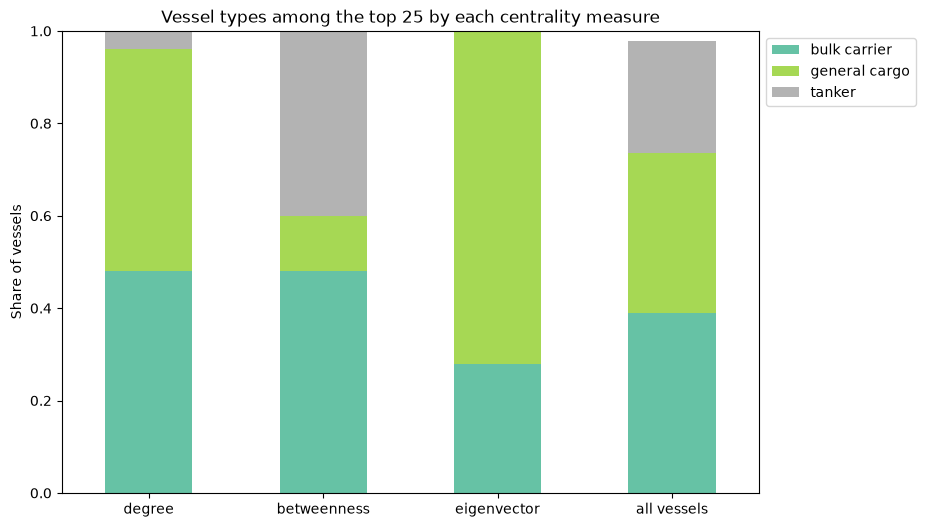

In [36]:
top25 = {m: cent.nlargest(25, m)["vessel_type"].value_counts(normalize=True) for m in ["degree", "betweenness", "eigenvector"]}
shares = pd.DataFrame(top25)
shares["all vessels"] = cent["vessel_type"].value_counts(normalize=True)
shares = shares.fillna(0).loc[["bulk carrier", "general cargo", "tanker"]]

shares.T.plot(kind="bar", stacked=True, colormap="Set2")
plt.ylabel("Share of vessels")
plt.title("Vessel types among the top 25 by each centrality measure")
plt.legend(bbox_to_anchor=(1, 1))
plt.xticks(rotation=0)
plt.show()

Tankers are over-represented among the high-**betweenness** vessels: they link groups of ships that otherwise don't interact. Different measures pick out different *roles*.

### Exercise 6
The column `named_in_grain_reports` marks the 15 vessels named in media reports about grain taken from occupied Ukraine. Using `cent`:
1. Compute each vessel's **percentile rank** by degree (hint: `cent["degree"].rank(pct=True)`).
2. What is the median percentile of the 15 named vessels? How many are in the top 10%?
3. Make a boxplot or strip plot of degree percentile for named vs. not-named vessels.

In [37]:
# your code here

## Spot the problem: what the network can't see

A journalist reads your results and writes:

> "Sanctioned vessels have *below-median* centrality in the Kerch transfer network. So sanctioned ships aren't central to the grain trade: sanctions have pushed them to the margins."

Check the premise, then critique the conclusion.

In [38]:
cent.groupby("sanctioned")[["degree", "betweenness"]].median()

,degree,betweenness
sanctioned,,
0,0.009015,0.000215
1,0.002774,0.000032


### Exercise 7
Write 3–4 bullet points. Consider: how were edges detected (what if one ship has its AIS **switched off**, like the lecture's "broker in the dark")? Would a sanctioned vessel have an incentive to be invisible? Is "fewer *visible* transfers" the same as "fewer transfers"? What data could test the journalist's claim?

*Your answer here (double-click to edit).*

## Communities

A **community** is a group of nodes with many edges inside and few between. **Louvain** repeatedly merges groups when that increases **modularity** (how much denser than chance the within-group edges are; above ~0.3 is notable). It only sees the edges, never vessel attributes.

In [39]:
comms = nx.community.louvain_communities(lcc, seed=0)
print(len(comms), "communities, modularity =", round(nx.community.modularity(lcc, comms), 2))

community = {node: i for i, c in enumerate(comms) for node in c}
cent["community"] = pd.Series(community).astype("Int64")   # vessels outside the largest component get <NA>

pd.crosstab(cent["community"], cent["vessel_type"], normalize="index").round(2)

7 communities, modularity = 0.53


vessel_type,bulk carrier,general cargo,other,tanker,unknown
community,,,,,
0,0.55,0.31,0.00,0.14,0.00
1,0.54,0.41,0.00,0.04,0.01
2,0.03,0.02,0.00,0.95,0.00
3,0.53,0.35,0.06,0.04,0.01
4,0.38,0.54,0.01,0.04,0.03
5,0.08,0.04,0.00,0.88,0.00
6,0.46,0.48,0.00,0.02,0.04


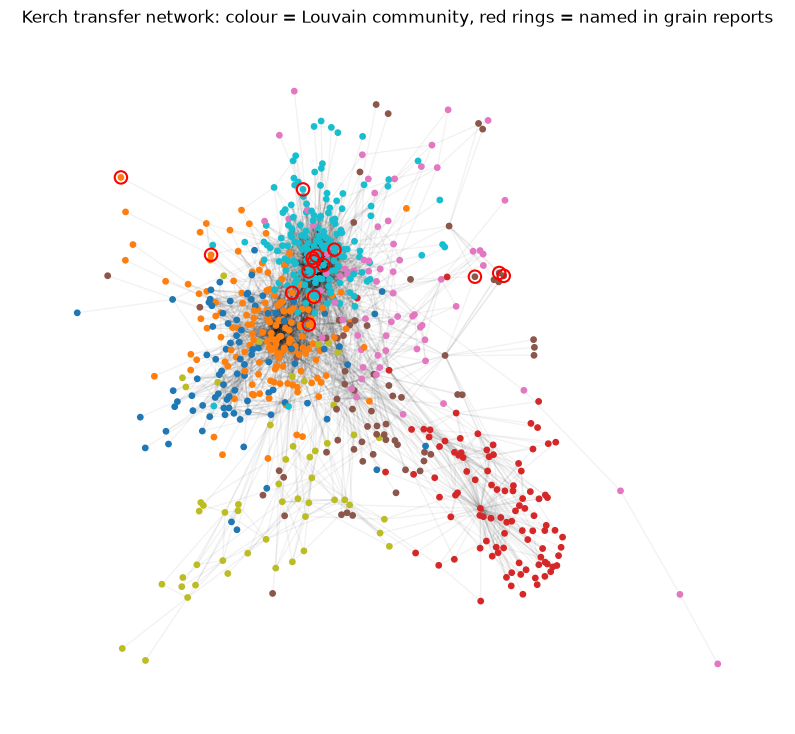

In [40]:
layout = nx.spring_layout(lcc, seed=3, k=0.15)
fig, ax = plt.subplots(figsize=(10, 9))
nx.draw_networkx_edges(lcc, layout, ax=ax, alpha=0.05)
nx.draw_networkx_nodes(lcc, layout, ax=ax, node_size=15, cmap="tab10",
                       node_color=[community[n] for n in lcc.nodes])
named = [n for n in lcc.nodes if cent.loc[n, "named_in_grain_reports"] == 1]
nx.draw_networkx_nodes(lcc, layout, nodelist=named, ax=ax, node_size=80, node_color="none", edgecolors="red", linewidths=1.5)
ax.set_title("Kerch transfer network: colour = Louvain community, red rings = named in grain reports")
ax.set_axis_off()
plt.show()

**Question:** The algorithm never saw vessel type, yet some communities are almost entirely tankers. What does that suggest about the transfer network? (Think: would a grain ship transfer to an oil tanker?)

### Exercise 8 (Extension)
Run Louvain on the **tube** network and draw it with the geographic `pos` from earlier, coloured by community. The algorithm never saw coordinates: are the communities geographic? Try `resolution=0.5` and `resolution=2` in `louvain_communities`: what changes?

In [41]:
# your code here

## Wrap-up

- **Vector** data = table + geometry column (points, lines, polygons). **Raster** data = a grid of values; resolution is cell size.
- Always check the **CRS**: measure distances, areas and buffers in a projected CRS (metres), not degrees. Python may only warn you.
- A **spatial join** attaches polygon (or nearest-feature) attributes to points; then aggregate with `groupby`. Check the row count after joining.
- Normalise by area before comparing zones; results depend on how zones are drawn (MAUP); nearby observations are not independent (autocorrelation).
- Networks: **degree distributions** reveal hubs; **small worlds** combine short paths with clustering; different **centrality** measures capture different roles; **communities** group nodes by connections alone.
- A network (or map) only contains what the sensor can see. Centrality can *prioritise* an investigation; it can't prove anything.